In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sample = np.loadtxt('sample1.csv', delimiter=',')
sample[:,1] *= -1

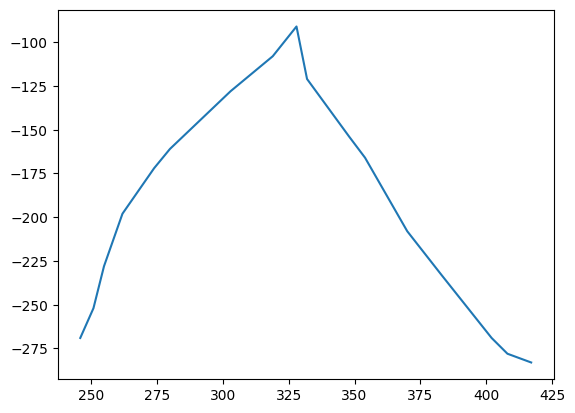

In [3]:
plt.plot(sample[:, 0], sample[:, 1])

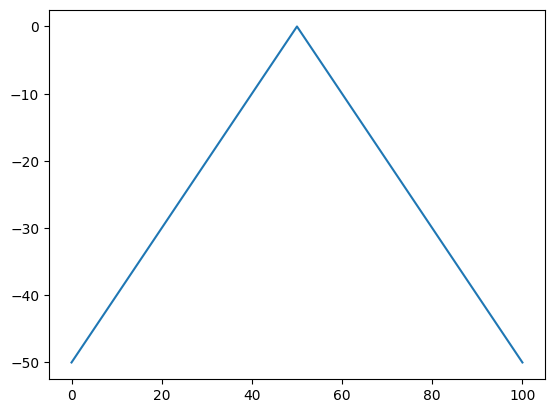

In [4]:
x = np.linspace(0, 100, len(sample))
target = lambda x: -np.abs(x-50)

plt.plot(x, target(x))
plt.show()

In [5]:
target_points = np.column_stack([x, target(x)])

# 2. Solve full affine transform
A_aug = np.hstack([sample, np.ones((sample.shape[0], 1))])
M, _, _, _ = np.linalg.lstsq(A_aug, target_points, rcond=None)

# 3. Apply affine transform
transformed = A_aug @ M


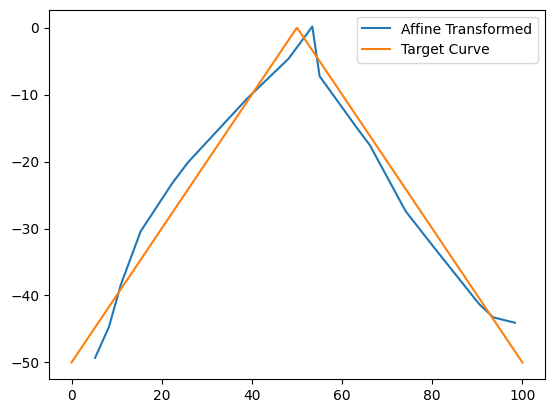

In [6]:
x_plot = np.linspace(0, 100, 500)

plt.plot(transformed[:, 0], transformed[:, 1], label="Affine Transformed")
plt.plot(x_plot, target(x_plot), label="Target Curve")
plt.legend()
plt.show()